###Μηχανική Μάθηση
####2η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ - 7ο εξάμηνο -Ακ. Έτος 2025-26



# ⚠️
`Επισημαίνεται ότι απαγορεύεται η ανάρτηση των λύσεων των εργαστηριακών ασκήσεων στο github, ή σε άλλες ιστοσελίδες. Η σχεδίαση και το περιεχόμενο των εργαστηριακών projects αποτελούν αντικείμενο πνευματικής ιδιοκτησίας της διδακτικής ομάδας του μαθήματος.`

### Εισαγωγή

Στην άσκηση αυτή θα εξερευνήσετε τεχνικές συσταδοποίησης και μείωσης διαστατικότητας σε εικόνες, ξεκινώντας από υπερφασματικά δεδομένα και προχωρώντας σε δεδομένα τηλεπισκόπησης.

- **Μέρος 1**: Θα χρησιμοποιήσετε τη μέθοδο συσταδοποίησης **k-means**, καθώς και την **fuzzy c-means**, σε συνδυασμό με τη μέθοδο μείωσης διαστατικότητας **PCA**, για την ανάλυση μιας υπερφασματικής εικόνας.

- **Μέρος 2**: Θα εργαστείτε με ένα σύνολο δεδομένων τηλεπισκόπησης και, με τη βοήθεια ενός προεκπαιδευμένου CNN, θα εξάγετε χαρακτηριστικά εικόνων για συσταδοποίηση, συγκρίνοντας τα αποτελέσματα με τη συσταδοποίηση με χρήση των pixels.

Ονοματεπώνυμο φοιτητή: Tsouroufli Zoi
Α.Μ.: 03122062

### 1. Φόρτωση υπερφασματικής εικόνας και των επισημειώσεων της

Κατεβάστε την υπερφασματική εικόνα `indian_pines_corrected.npy` και τις αντίστοιχες επισημειώσεις `indian_pines_gt.npy` από το Google Drive:
https://drive.google.com/drive/folders/1DQiI75ll5h79-UTaq_nmcwfz4h3cxDVM?usp=sharing

**1.α. Φορτώστε την εικόνα και τις αντίστοιχες επισημειώσεις με χρήση της συνάρτησης np.load.**

In [1]:
import numpy as np

#φόρτωση της υπερφασματικής εικόνας
image_data = np.load('indian_pines_corrected.npy')

#φόρτωση των αντίστοιχων επισημειώσεων (ground truth)
gt_data = np.load('indian_pines_gt.npy')

#διαστάσεις
print("Image shape:", image_data.shape)
print("Ground Truth shape:", gt_data.shape)

Image shape: (145, 145, 200)
Ground Truth shape: (145, 145)


Η τρίτη διάσταση στο image_data είναι τα φασματικά κανάλια

Οι επισημειώσεις που φορτώσατε αντιστοιχούν κάθε πιξελ της υπερφασματικής εικόνας σε ένα τύπο από διαφορετικές κατηγορίες:

```python
classes = [
    "Undefined",
    "Alfalfa",
    "Corn-notill",
    "Corn-mintill",
    "Corn",
    "Grass-pasture",
    "Grass-trees",
    "Grass-pasture-mowed",
    "Hay-windrowed",
    "Oats",
    "Soybean-notill",
    "Soybean-mintill",
    "Soybean-clean",
    "Wheat",
    "Woods",
    "Buildings-Grass-Trees-Drives",
    "Stone-Steel-Towers"
]
```

In [2]:
classes = [
    "Undefined",
    "Alfalfa",
    "Corn-notill",
    "Corn-mintill",
    "Corn",
    "Grass-pasture",
    "Grass-trees",
    "Grass-pasture-mowed",
    "Hay-windrowed",
    "Oats",
    "Soybean-notill",
    "Soybean-mintill",
    "Soybean-clean",
    "Wheat",
    "Woods",
    "Buildings-Grass-Trees-Drives",
    "Stone-Steel-Towers"
]

### 2. Οπτικοποίηση και Διερευνητική ανάλυση δεδομένων

Παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. Βρείτε το ύψος και το πλάτος της εικόνας, καθώς και τον αριθμό των υπερφασματικών καναλιών

2β. Σχεδιάστε με χρήση της matplotlib το 3ο, 65ο, και 95ο κανάλι της εικόνας στο ίδιο διάγραμμα

2γ. Υπολογίστε τον αριθμό των διαφορετικών κατηγοριών καλλιέργειας στις επισημειώσεις

2δ. Σχεδιάστε με χρήση της matplotlib τις επισημειώσεις. Προσθέστε επιπλέον επεξηγηματική λεζάντα με χρήση της βιβλιοθήκης κάθε επισημείωσης (χρησιμοποιήστε τη λίστα `classes` που σας δόθηκε προηγουμένως.)

2ε. Υπολογίστε πόσα pixel της εικόνας αντιστοιχούν σε κάθε επισημείωση.

**2α. Βρείτε το ύψος και το πλάτος της εικόνας, καθώς και τον αριθμό των υπερφασματικών καναλιών**

In [3]:
#πρώτο όρισμα ύψος, δεύτερο όρισμα πλάτος, τρίτο όρισμα αριθμός υπερφασματικών καναλιών
print("Image shape:", image_data.shape)

Image shape: (145, 145, 200)


**2β. Σχεδιάστε με χρήση της matplotlib το 3ο, 65ο, και 95ο κανάλι της εικόνας στο ίδιο διάγραμμα**

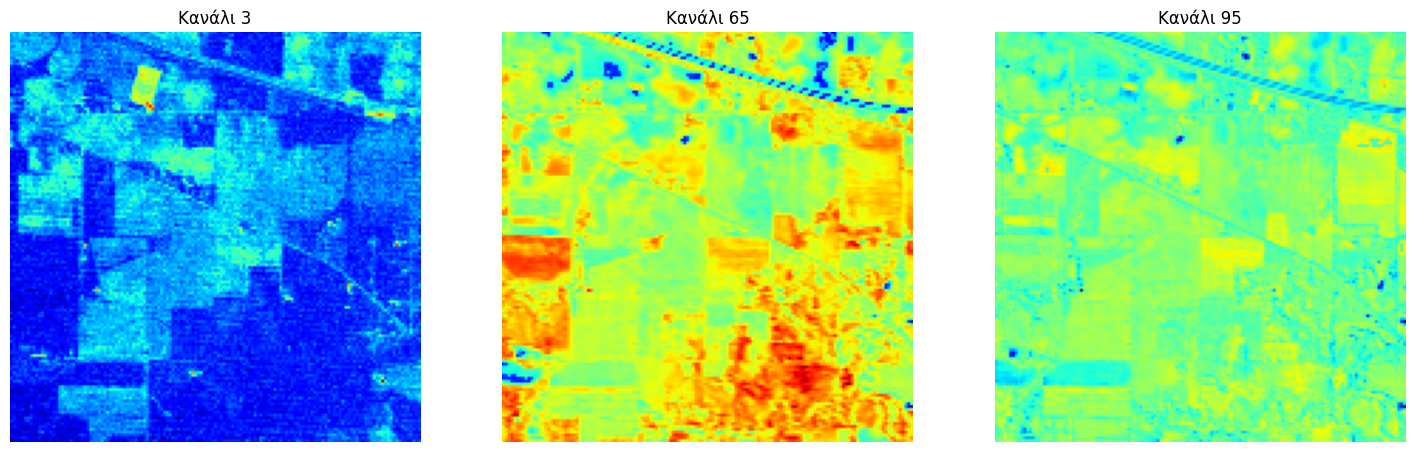

In [4]:
import matplotlib.pyplot as plt

#γράφημα
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

#κανάλι 3
ax1.imshow(image_data[:, :, 2], cmap='jet') #παίρνουμε όλα τα pixels ύψους και πλάτους και επιλέγουμε το κανάλι 3
ax1.set_title('Κανάλι 3')
ax1.axis('off') #κρύβει άξονες

#κανάλι 65
ax2.imshow(image_data[:, :, 64], cmap='jet')
ax2.set_title('Κανάλι 65')
ax2.axis('off')

#κανάλι 94
ax3.imshow(image_data[:, :, 94], cmap='jet')
ax3.set_title('Κανάλι 95')
ax3.axis('off')

#εμφάνιση
plt.show()

Εάν θέλω να δημιουργήσω μια έγχρωμη σύνθετη εικόνα RGB: Στοιβάζω τα τρία κανάλια και το καθ'ένα παίζει τον ρόλο του κόκκινου, πράσινου και μπλε αντίστοιχα

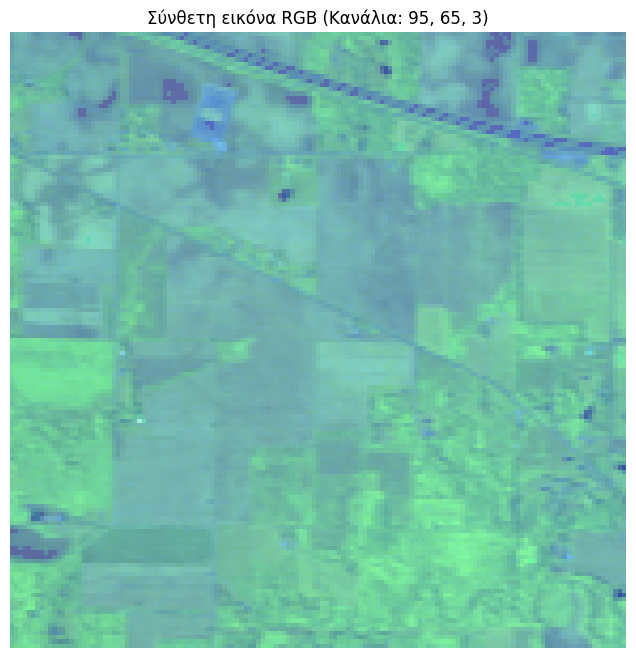

In [5]:
#επιλέγουμε τα 3 κανάλια που ζητήθηκαν (θέσεις πίνακα : 2, 64, 94)
#φτιάχνουμε έναν πίνακα με διαστάσεις (145, 145, 3) με το κόκκινο να αντιστοιχίζεται στο κανάλι 95, το πράσινο στο 65 και το μπλε στο 3
rgb_image = image_data[:, :, [94, 64, 2]]

#κάνουμε κανονικοποίηση ανάμεσα στις τιμές 0 και 1, διαιρώντας με τη μέγιστη τιμή
rgb_image_normalized = rgb_image.astype(float) / np.max(rgb_image)

#εμφανίζουμε
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image_normalized)
plt.title('Σύνθετη εικόνα RGB (Κανάλια: 95, 65, 3)')
plt.axis('off')
plt.show()

**2γ. Υπολογίστε τον αριθμό των διαφορετικών κατηγοριών καλλιέργειας στις επισημειώσεις**

In [6]:
#βρίσκουμε τις μοναδικές τιμές (classes)στο gt_data
classes2 = np.unique(gt_data) #ποιες
num_classes = len(classes2) #πόσες

print(f"Οι κατηγορίες που βρέθηκαν είναι: {classes}")
print(f"Συνολικός αριθμός διαφορετικών κατηγοριών: {num_classes}")

Οι κατηγορίες που βρέθηκαν είναι: ['Undefined', 'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers']
Συνολικός αριθμός διαφορετικών κατηγοριών: 17


Παρατηρούμε ότι ο συνολικός αριθμός διαφορετικών κατηγοριών είναι 17 όσα και τα στοιχεία της λίστας classes που μας δόθηκαν εξαρχής.
Υπάρχει λοιπόν, αντιστοίχιση ανάμεσα στους αριθμούς μέσα στον πίνακα gt_data και στη λίστα classes.
Συγκεκριμένα:
Ο αριθμός στο gt_data είναι ο δείκτης (index) της λίστας.
Η λίστα classes είναι το λεξικό που καθορίζει τι σημαίνει ο κάθε αριθμός.

In [7]:
print("Αντιστοίχιση Αριθμού -> Ονόματος:")
for index in classes2:
    # Προσοχή: Βεβαιώσου ότι το index δεν ξεπερνά το μέγεθος της λίστας
    if index < len(classes):
        print(f"Ο αριθμός {index} αντιστοιχεί σε: {classes[index]}")

Αντιστοίχιση Αριθμού -> Ονόματος:
Ο αριθμός 0 αντιστοιχεί σε: Undefined
Ο αριθμός 1 αντιστοιχεί σε: Alfalfa
Ο αριθμός 2 αντιστοιχεί σε: Corn-notill
Ο αριθμός 3 αντιστοιχεί σε: Corn-mintill
Ο αριθμός 4 αντιστοιχεί σε: Corn
Ο αριθμός 5 αντιστοιχεί σε: Grass-pasture
Ο αριθμός 6 αντιστοιχεί σε: Grass-trees
Ο αριθμός 7 αντιστοιχεί σε: Grass-pasture-mowed
Ο αριθμός 8 αντιστοιχεί σε: Hay-windrowed
Ο αριθμός 9 αντιστοιχεί σε: Oats
Ο αριθμός 10 αντιστοιχεί σε: Soybean-notill
Ο αριθμός 11 αντιστοιχεί σε: Soybean-mintill
Ο αριθμός 12 αντιστοιχεί σε: Soybean-clean
Ο αριθμός 13 αντιστοιχεί σε: Wheat
Ο αριθμός 14 αντιστοιχεί σε: Woods
Ο αριθμός 15 αντιστοιχεί σε: Buildings-Grass-Trees-Drives
Ο αριθμός 16 αντιστοιχεί σε: Stone-Steel-Towers


**2δ. Σχεδιάστε με χρήση της matplotlib τις επισημειώσεις. Προσθέστε επιπλέον επεξηγηματική λεζάντα με χρήση της βιβλιοθήκης κάθε επισημείωσης (χρησιμοποιήστε τη λίστα `classes` που σας δόθηκε προηγουμένως.)**

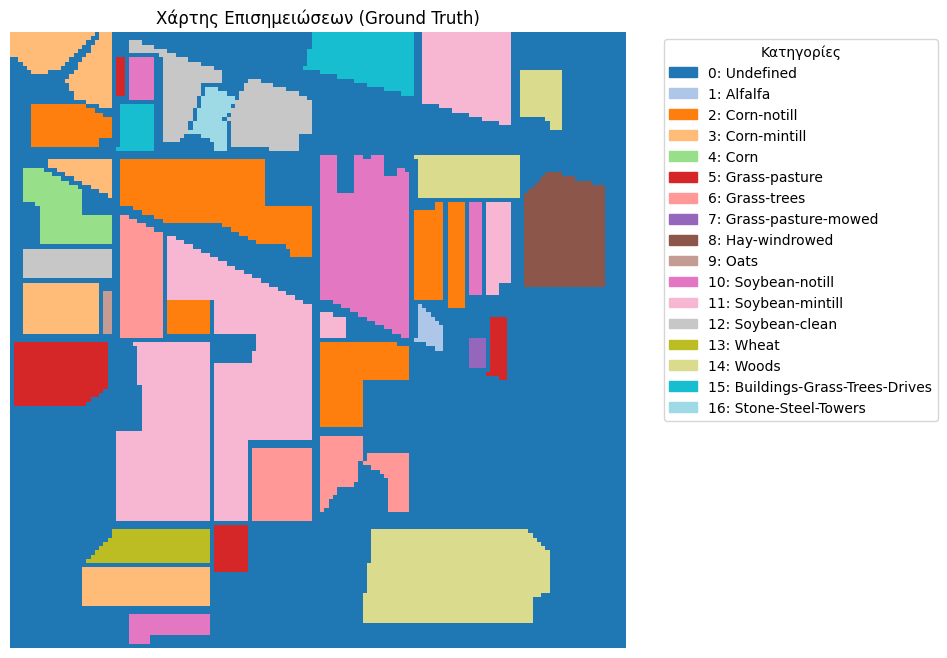

In [8]:
import matplotlib.patches as mpatches

#ρυθμίζουμε τον χρωματικό χάρτη, χρησιμοποιώντας το 'tab20' με 20 διαφορετικά χρώματα
cmap = plt.get_cmap('tab20')

#γράφημα
fig, ax = plt.subplots(figsize=(12, 8)) # Μεγαλώνουμε λίγο το σχήμα

# εμφανίζουμε την εικόνα gt_data, ορίζοντας vmin=0 και vmax=16 ώστε τα χρώματα να μοιραστούν σωστά σε όλες τις πιθανές κλάσεις.
im = ax.imshow(gt_data, cmap=cmap, vmin=0, vmax=len(classes)-1)

ax.set_title("Χάρτης Επισημειώσεων (Ground Truth)")
ax.axis('off')

#λεζάντα
#δημιουργούμε έναν νέο πίνακα στον οποίο θα αποθηκεύσουμε τα κουτάκια
legend_patches = []

for index in classes2:
    #βρίσκουμε το χρώμα που αντιστοιχεί σε αυτόν τον αριθμό και διαιρούμε με το 16 για κανονικοποίηση που θέλει το cmap
    color = cmap(index / (len(classes)-1))

    #παίρνουμε το όνομσ από τη λίστα classes
    label_text = f"{index}: {classes[index]}"

    #δημιουργούμε ένα "patch"
    patch = mpatches.Patch(color=color, label=label_text)
    legend_patches.append(patch)

#εμφανίζουμε
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Κατηγορίες")

plt.show()

**2ε. Υπολογίστε πόσα pixel της εικόνας αντιστοιχούν σε κάθε επισημείωση.**

In [9]:
#χρησιμοποιούμε το return_counts=True για να πάρουμε και το πλήθος
unique_classes, counts = np.unique(gt_data, return_counts=True)

print("Κατανομή Pixels ανά Κατηγορία")

for i in range(len(unique_classes)):
    class_index = unique_classes[i]  #ο αριθμός της κλάσης
    count = counts[i]                #πόσα pixels
    name = classes[class_index]      #όνομα

    print(f"{name} (ID: {class_index}): {count} pixels")

Κατανομή Pixels ανά Κατηγορία
Undefined (ID: 0): 10776 pixels
Alfalfa (ID: 1): 46 pixels
Corn-notill (ID: 2): 1428 pixels
Corn-mintill (ID: 3): 830 pixels
Corn (ID: 4): 237 pixels
Grass-pasture (ID: 5): 483 pixels
Grass-trees (ID: 6): 730 pixels
Grass-pasture-mowed (ID: 7): 28 pixels
Hay-windrowed (ID: 8): 478 pixels
Oats (ID: 9): 20 pixels
Soybean-notill (ID: 10): 972 pixels
Soybean-mintill (ID: 11): 2455 pixels
Soybean-clean (ID: 12): 593 pixels
Wheat (ID: 13): 205 pixels
Woods (ID: 14): 1265 pixels
Buildings-Grass-Trees-Drives (ID: 15): 386 pixels
Stone-Steel-Towers (ID: 16): 93 pixels


### 3. Εύρεση φασματικών υπογραφών

**3.α. Μετατρέψτε την υπερφασματική εικόνα και τις επισημειώσεις σε μορφή κατάλληλη για περαιτέρω επεξεργασία. Η εικόνα θα πρέπει να μετατραπεί σε πίνακα N x Κ, όπου Ν τα pixel και K ο αριθμός των καναλιών. Οι επισημειώσεις αντίστοιχα θα πρέπει να μετατραπούν σε διάνυσμα μήκους Ν. Στη συνέχεια, "διώχτε" όσα δεδομένα είναι επισημειωμένα ως Undefined.**

💡 Χρησιμοποιήστε την `numpy reshape`

In [10]:
#reshape

#μετατρέπουμε την εικόνα σε πίνακα(NxK)
image_ready = image_data.reshape(-1, image_data.shape[2]) #υπολόγισε μήκος Ν κρατώντας σταθερό τον αριθμό των καναλιών

# μετατρέπουμε τις επισημειώσεις σε διάνυσμα (N)
gt_data_ready = gt_data.reshape(-1)

print("διαστάσεις πριν το φιλτράρισμα:")
print(f"image_ready shape: {image_ready.shape}")
print(f"gt_data_ready shape: {gt_data_ready.shape}")

#αφαίρεση των undefined (class 0)
#δημιουργούμε μια μάσκα (φίλτρο) κρατώντας μόνο τα δεδομένα του gt_data_ready που δεν είναι 0, δηλαδή τα pixels που έχουν κάποια καλλιέργεια
valid_pixels_mask = gt_data_ready > 0

# Εφαρμόζουμε τη μάσκα και στα δεδομένα (X) και στις ετικέτες (y)
image_clean = image_ready[valid_pixels_mask]
gt_data_clean = gt_data_ready[valid_pixels_mask]

print("διαστάσεις μετά το φιλτράρισμα (έτοιμα για εκπαίδευση):")
print(f"image_clean shape: {image_clean.shape}")
print(f"gt_data_clean shape: {gt_data_clean.shape}")

διαστάσεις πριν το φιλτράρισμα:
image_ready shape: (21025, 200)
gt_data_ready shape: (21025,)
διαστάσεις μετά το φιλτράρισμα (έτοιμα για εκπαίδευση):
image_clean shape: (10249, 200)
gt_data_clean shape: (10249,)


**3.β. Επιλέξτε ένα τυχαίο pixel της εικόνα από κάθε κατηγορία, και σχεδιάστε την υπερφασματική υπογραφή των επιλεγμένων πίξελ.**

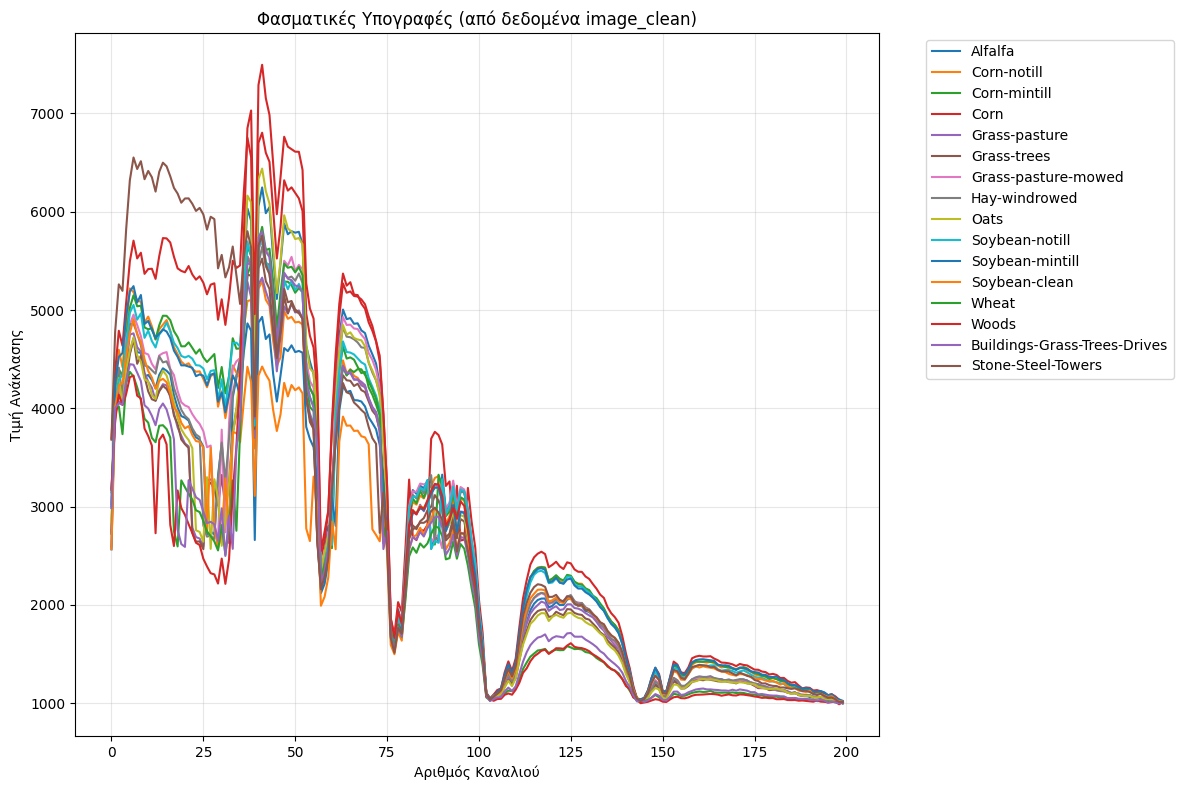

In [11]:
import random

#γράφημα
plt.figure(figsize=(12, 8))

# βρίσκουμε ποιες μοναδικές κατηγορίες υπάρχουν μέσα στο gt_data_clean
unique_classes_clean = np.unique(gt_data_clean)

for class_id in unique_classes_clean:
    # αποθηκεύουμε τις θέσεις (indices) στον πίνακα gt_data_clean που αντιστοιχούν στην κατηγορία
    indices = np.where(gt_data_clean == class_id)[0] #επιστρέφει tuple

    #διαλέγουμε τυχαία μία από αυτές τις θέσεις
    random_idx = random.choice(indices)

    #παίρνουμε την υπογραφή απευθείας από τον πίνακα image_clean, αφού η γραμμή random_idx περιέχει τις 200 τιμές που θέλουμε
    signature = image_clean[random_idx]

    #εμφανίζουμε
    plt.plot(signature, label=classes[class_id])

plt.title('Φασματικές Υπογραφές (από δεδομένα image_clean)')
plt.xlabel('Αριθμός Καναλιού')
plt.ylabel('Τιμή Ανάκλασης')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**3.γ. Σημειώστε τις παρατηρήσεις σας και τα συμπεράσματα σας. Προσπαθήστε να απαντήσετε στις ακόλουθες ερωτήσεις:**
    
* Με βάση τα προηγούμενα διαγράμματα θεωρείτε ότι κάποιες καλλιέργειες είναι πιο εύκολα διαχωρίσιμες από άλλες με βάση τη φασματική υπογραφή τους;
* Θεωρείτε ότι όλα τα κανάλια παρέχουν χρήσιμη πληροφορία για το διαχωρισμό;

Στον κώδικα χρησιμοποιούμε την εντολή random.choice, που σημαίνει ότι κάθε φορά που τρέχουμε το κελί, διαλέξουμε στην τύχη ένα διαφορετικό pixel. Άρα τα αποτελέσματα και οι παρατηρήσεις που κάνουμε δεν είναι συστηματικά κάθε φορά μεταβάλλονται. Για αυτό θα πάρουμε τον μέσο όρο όλων των pixels για κάθε καλλιέργεια και θα παρατηρήσουμε καλύτερα την ταυτότητα της κάθε καλλιέργειας.  

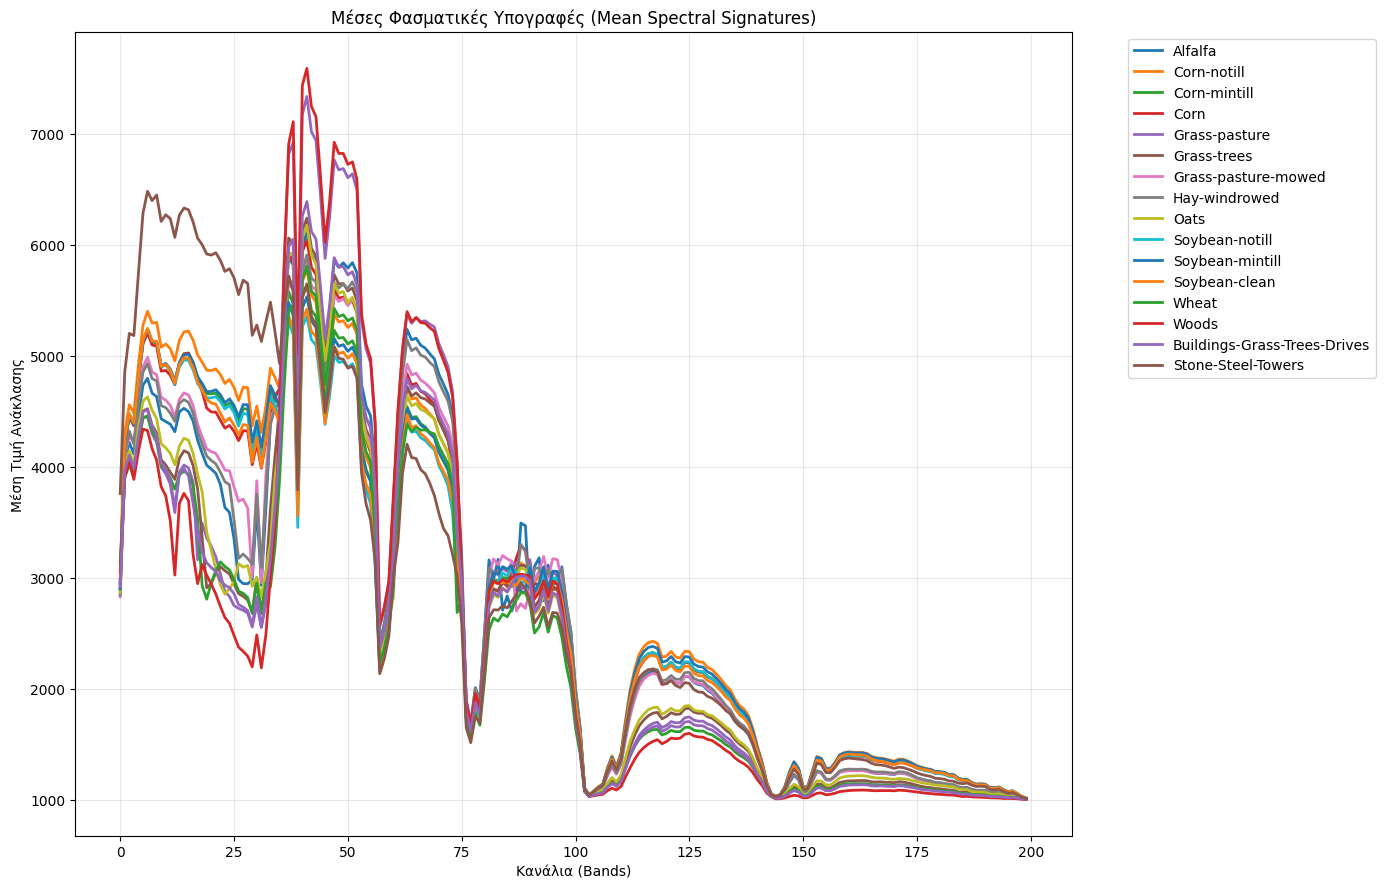

In [12]:
plt.figure(figsize=(14, 9))

for class_id in unique_classes_clean:
    indices = np.where(gt_data_clean == class_id)[0]

    #υπολογίζουμε τον μέσο όρο (axis=0)
    mean_signature = np.mean(image_clean[indices], axis=0)

    #μέση υπογραφή
    plt.plot(mean_signature, label=classes[class_id], linewidth=2)

plt.title('Μέσες Φασματικές Υπογραφές (Mean Spectral Signatures)')
plt.xlabel('Kανάλια (Bands)')
plt.ylabel('Μέση Τιμή Ανάκλασης')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Για τον διαχωρισμό παρατηρούμε ότι:
*   Οι καλλιέργειες μοιάζουν αρκετά, άρα παρουσιάζουν παρόμοια φασματική συμπεριφορά. Καλλιέργειες όπως Corn, Soybean, Alfalfa, Wheat κλπ, ακολουθούν παρόμοια διαδρομή.Κάνουν μια "κοιλιά" στην αρχή, ανεβαίνουν απότομα στο κανάλι 30-40 και βυθίζονται στα κανάλια 75 και 100. Μόνη τους διαφορά στην ένταση/ύψος δηλαδή στην μέση τιμή ανάκλασης.
*   Οι ανθρωπογενείς κατασκευές (Stone-Steel-Towers / καφέ γραμμή) διαχωρίζονται εύκολα από τη βλάστηση, καθώς έχουν τελείως διαφορετικό σχήμα καμπύλης στα πρώτα 40 κανάλια.

Για τη χρησιμότητα των καναλιών παρατηρούμε ότι:
*   Yπάρχουν ορισμένες νεκρές ζώνες, παρατηρούμε δηλαδή έντονες βυθίσεις (περίπου στα κανάλια 75 και 105) όπου η τιμή ανάκλασης για όλες τις κατηγορίες πέφτει πολύ χαμηλά. Αυτές δεν παρέχουν ουσιαστικά καμία πληροφορία διαχωρισμού
*   Σε πολλά κανάλια οι γραμμές εμφανίζουν επικάλυψη(π.χ. μετά το 150), συμπίπτουν δηλαδή, σχεδόν απόλυτα, άρα εκείνα τα κανάλια δεν προσφέρουν διακριτή πληροφορία για την ταξινόμηση.

**3.δ. Σχεδιάστε ένα heatmap, που να δείχνει τη συσχέτιση μεταξύ των διαφορετικών καναλιών**

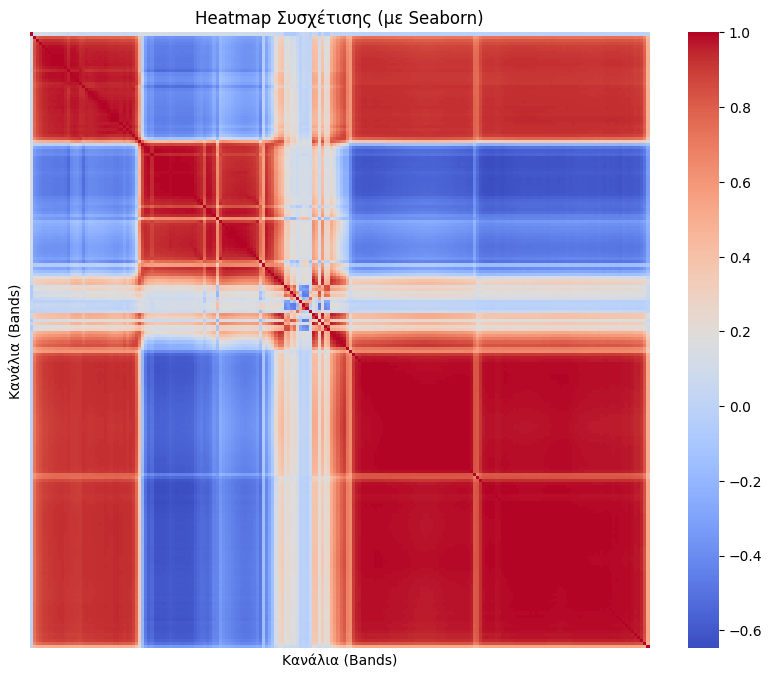

In [13]:
import seaborn as sns

#υπολογίζουμε τον πίνακα συσχέτισης
correlation_matrix = np.corrcoef(image_clean, rowvar=False)

#σχεδιάζουμε
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)

plt.title('Heatmap Συσχέτισης (με Seaborn)')
plt.xlabel('Κανάλια (Bands)')
plt.ylabel('Κανάλια (Bands)')
plt.show()

### 4. Συσταδοποίηση με χρήση του αλγορίθμου KMeans

 4.α. Εφαρμόστε τον αλγόριθμο KMeans (sklearn.cluster) στα δεδομένα (εφόσον κάνατε την προεπεξεργασία του Βήματος 3). Χρησιμοποιήστε την τιμή `n_cluster=17`.

Αξιολογήστε την απόδοση του αλγορίθμου χρησιμοποιώντας τις ακόλουθες μετρικες:

* Adjusted Rand Index
* Silhouette Score

Ο Adjusted Rand Index (ARI) υπολογίζει πόσα ζεύγη σημείων ταξινομήθηκαν σωστά είτε στην ίδια συστάδα είτε σε διαφορετικές συστάδες χρησιμοποιώντας τις πραγματικές κατηγορίες, λαμβάνοντας υπόψη τυχαίες αντιστοιχίσεις. Έχει τιμές από -1 (πολύ κακή συσταδοποίηση) έως 1 (τέλεια ευθυγράμμιση με τις κατηγορίες), ενώ τιμή 0 υποδηλώνει τυχαία συσταδοποίηση. Είναι χρήσιμο για την αξιολόγηση της ακρίβειας σε δεδομένα με γνωστές κατηγορίες.

Αντιθέτως το  Silhouette Score μετρά πόσο καλά ένα σημείο δεδομένων ταιριάζει στη συστάδα του σε σχέση με τις υπόλοιπες συστάδες. Υπολογίζει τη μέση απόσταση ενός σημείου από τα υπόλοιπα σημεία της ίδιας συστάδας (cohesion) και τη μέση απόσταση από τα σημεία της πλησιέστερης άλλης συστάδας (separation). Το σκορ κυμαίνεται από -1 έως 1, όπου τιμές κοντά στο 1 υποδηλώνουν καλά ορισμένες συστάδες, τιμές κοντά στο 0 σημαίνουν αλληλοεπικαλυπτόμενες συστάδες, ενώ αρνητικές τιμές υποδεικνύουν κακή ανάθεση σε συστάδα.

Ο Silhouette Score είναι ένα μέτρο εσωτερικής αξιολόγησης, που εξετάζει τη συνοχή και τον διαχωρισμό των συστάδων χωρίς να λαμβάνει υπόψη πραγματικές κατηγορίες. Αντίθετα, ο Adjusted Rand Index (ARI) είναι μέτρο εξωτερικής αξιολόγησης, που συγκρίνει τις συστάδες με τις πραγματικές κατηγορίες (ground truth). Η χρήση και των δύο μαζί παρέχει μια συνολική εικόνα της ποιότητας της συσταδοποίησης.

**4.α. Εφαρμόστε τον αλγόριθμο KMeans (sklearn.cluster) στα δεδομένα (εφόσον κάνατε την προεπεξεργασία του Βήματος 3). Χρησιμοποιήστε την τιμή n_cluster=17.**

In [14]:
from sklearn.cluster import KMeans

#δημιουργούμε το μοντέλο KMeans
kmeans = KMeans(n_clusters=17, random_state=42, n_init=10) #17 ομάδες (clusters), θα τρέξει 10 φορές (επαναλήψεις) για μα βρει το βέλτιστο

#training στα δεδομένα μας (image_clean)- τα επεξεργασμένα δεδομένα μας
kmeans.fit(image_clean)

#αποτελέσματα-labels
#πίνακας που δηλώνει σε ποια ομάδα/καλλιέργεια (0-16) ανήκει το κάθε pixel
kmeans_labels = kmeans.labels_

print(f"Δημιουργήθηκαν ετικέτες με σχήμα: {kmeans_labels.shape}")
print(f"Μοναδικές ομάδες που βρέθηκαν: {np.unique(kmeans_labels)}")

Δημιουργήθηκαν ετικέτες με σχήμα: (10249,)
Μοναδικές ομάδες που βρέθηκαν: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


**Αξιολογήστε την απόδοση του αλγορίθμου χρησιμοποιώντας τις ακόλουθες μετρικες:**

* Adjusted Rand Index
* Silhouette Score

In [15]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

print("υπολογισμός μετρικών αξιολόγησης")

#Adjusted Rand Index (ARI)
ari = adjusted_rand_score(gt_data_clean, kmeans_labels) #συγκρίνουμε την πραγματικότητα gt_data με τα
                                                        #αποτελέσματα της κατηγοριοποίησης του kmeans
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

#Silhouette Score
# Ελέγχουμε πόσο καλά διαχωρίζονται τα δεδομένα (X_clean) με βάση τις ετικέτες (kmeans_labels)
sil = silhouette_score(image_clean, kmeans_labels) #συγκρίνουμε τον διαχωρισμό των kmeans_labels με τα δεδομένα
                                                   #image_clean που διαθέτουμε
print(f"Silhouette Score: {sil:.4f}")

υπολογισμός μετρικών αξιολόγησης
Adjusted Rand Index (ARI): 0.2035
Silhouette Score: 0.2827


Από τα αποτελέσματα που βλέπουμε στους μετρικούς δείκτες (ARI: 0.2035 και Silhouette: 0.2827), συμπεραίνουμε ότι ο αλγόριθμος δυσκολεύεται πάρα πολύ να ξεχωρίσει τις καλλιέργειες.
Συγκεκριμένα από το ARI score συμπεραίνουμε ότι ο αλγόριθμος δεν κατάφερε να αντιστοιχίσει/ διαχωρίσει σωστά τις ομάδες που έφτιαξε με την πραγματικότητα (Ground Truth).
Επίσης, χαμηλό Silhouette Score (0.28) επιβεβαιώνει ότι οι συστάδες δεν είναι καλά διαχωρισμένες αλλά παρουσιάζουν σημαντική επικάλυψη
Άρα, η φασματική πληροφορία από μόνη της, χωρίς μείωση διαστάσεων, δεν επαρκεί για τον ακριβή διαχωρισμό των παρόμοιων καλλιεργειών.

**4.β. Εφαρμογή του αλγορίθμου Fuzzy C-Means**

Ο αλγόριθμος **Fuzzy C-Means** δεν περιλαμβάνεται στο scikit-learn, αλλά μπορούμε να τον εφαρμόσουμε χρησιμοποιώντας τη βιβλιοθήκη `fcmeans`.

#### **Βήμα 1: Εγκατάσταση της βιβλιοθήκης**
Πρώτα, εγκαταστήστε τη βιβλιοθήκη `fcmeans` εκτελώντας την παρακάτω εντολή σε ένα κελί:

```bash
!pip install fuzzy-c-means
```

#### **Βήμα 2: Εκτέλεση του αλγορίθμου**
Η fcmeans παρέχει λειτουργικότητα αντίστοιχη με τον τρόπο εκπαίδευσης του scikit-learn, επιτρέποντας εύκολη ενσωμάτωση στη ροή εργασιών σας.

Για περισσότερες πληροφορίες σχετικά με τη χρήση της βιβλιοθήκης, δείτε το documentation: https://fuzzy-c-means.readthedocs.io/en/latest/

Υπολογίστε πάλι το Silhouette Score και το ARI και συγκρίνετε με τις προηγούμενες μεθόδους.



In [16]:
!pip install fuzzy-c-means

In [17]:
from fcmeans import FCM
from sklearn.metrics import adjusted_rand_score, silhouette_score

#δημιουργούμε το μοντέλο fcmeans
#η ασάφεια (fuzziness καθορίζει πόσο αυστηρά είναι τα όρια μεταξύ των ομάδων)
fcm = FCM(n_clusters=17, m=2.0) #m=2 standard τιμή ασάφειας fuzziness

#εκπαίδευση (fit)
fcm.fit(image_clean)
#γυρνάει τα κέντρα (μέση φασματική υπογραφή για κάθε καλλιέργεια) και τον πίνακα συμμετοχής
#ο πίνακας συμμετοχής δηλώνει για κάθε pixel ποια είναιη πιθανότητα του να ανήκει στην κάθε καλλιέργεια

#πρόβλεψη (predict)
#το μοντέλο δίνει την επικρατέστερη ομάδα/καλλιέργεια για κάθε pixel
fcm_labels = fcm.predict(image_clean)

print("υπολογισμός μετρικών αξιολόγησης")

# Adjusted Rand Index (ARI)
ari_fcm = adjusted_rand_score(gt_data_clean, fcm_labels)
print(f"Fuzzy C-Means ARI: {ari_fcm:.4f}")

# Silhouette Score
sil_fcm = silhouette_score(image_clean, fcm_labels)
print(f"Fuzzy C-Means Silhouette Score: {sil_fcm:.4f}")

υπολογισμός μετρικών αξιολόγησης
Fuzzy C-Means ARI: 0.1753
Fuzzy C-Means Silhouette Score: 0.1906


Θα περιμέναμε να αυξηθούν οι μετρικές αξιολόγησης και να βελτιωθεί η ταξινόμηση σε καλλλιέργειες. Όμως λόγω της ύπαρξης 200 διαφορετικών καναλιών ο fcmeans μπερδεύεται. Επίσης με 200 κανάλια η έννοια της απόστασης χάνει το νόημα της.

In [19]:
#from google.colab import drive
#drive.mount('/content/drive')

### 5. Μείωση διαστατικότητας δεδομένων

**5.α. Εφαρμόστε στα δεδομένα τη μέθοδο μείωσης διαστατικότητας PCA. Επιλέξτε `n_components=3`**

In [22]:
from sklearn.decomposition import PCA

print(f"Αρχικές διαστάσεις δεδομένων: {image_clean.shape}")

#δημιουργούμε το μοντέλο PCA
pca = PCA(n_components=3) #ζητάμε 3 συνιστώσες

#fit-transform 200 κανάλια σε 3
#το PCA ψάχνει να βρει νέους άξονες όπου τα δεδομένα έχουν τη μέγιστη δυνατή διακύμανση
image_pca = pca.fit_transform(image_clean) #αφού βρεις του (3 εδώ) άξονες αλλάζει τις συντεταγμένες των pixels ως προσ αυτούς

print(f"Νέες διαστάσεις δεδομένων (μετά το PCA): {image_pca.shape}") #έλεγχος διαστάσεων

Αρχικές διαστάσεις δεδομένων: (10249, 200)
Νέες διαστάσεις δεδομένων (μετά το PCA): (10249, 3)
Πληροφορία ανά συνιστώσα: [0.66452713 0.2654258  0.01206197]
Συνολική πληροφορία που διατηρήθηκε: 94.20%


**5.β. Τι ποσοστό της διακύμανσης των δεδομένων διατηρείτε με `n_components=3`?**
Hint: sklearn.decomposition.PCA.explained_variance_ratio_

In [23]:
#το explained_variance_ratio_ μας λέει πόσο % της αρχικής πληροφορίας κράτησε κάθε component
var_ratio = pca.explained_variance_ratio_
print(f"Πληροφορία ανά συνιστώσα: {var_ratio}")
print(f"Συνολική πληροφορία που διατηρήθηκε: {sum(var_ratio) * 100:.2f}%")

Πληροφορία ανά συνιστώσα: [0.66452713 0.2654258  0.01206197]
Συνολική πληροφορία που διατηρήθηκε: 94.20%


Με τη χρήση της μεθόδου PCA και την επιλογή 3 κύριων συνιστωσών (n_components=3), διατηρήθηκε το 94.20% της συνολικής διακύμανσης των δεδομένων.
Η υψηλή διατήρηση πληροφορίας αποδεικνύει ότι τα υπερφασματικά δεδομένα που μασ δώθηκαν αρχικά περιείχαν μεγάλο βαθμό πλεονασμού.

### 6. Συνδυασμός μείωσης διαστατικότητας και kmeans

**6.α. Εφαρμόστε τον αλγόριθμο kmeans στα δεδομένα μειωμένης διαστατικότητας `n_components=3`, και υπολογίστε εκ νέου τις μετρικές. Τι συμπεράσματα βγάζετε;**

In [24]:
kmeans_pca = KMeans(n_clusters=17, random_state=42, n_init=10)
kmeans_pca.fit(image_pca)  #image_pca αντί για image_clean

#προβλέψεις
labels_pca = kmeans_pca.labels_

#μετρικές αξιολόγησης
print("Αποτελέσματα μετά το PCA:")

# ARI (συγκρίνουμε με την πραγματικότητα (Ground Truth))
ari_pca = adjusted_rand_score(gt_data_clean, labels_pca)
print(f"Adjusted Rand Index (ARI): {ari_pca:.4f}")

# Silhouette Score (πόσο καλά διαχωρίζονται οι ομάδες στον νέο χώρο)
sil_pca = silhouette_score(image_pca, labels_pca) #συγκρίνουμε πάνω στο image_pca όχι στο αρχικό
print(f"Silhouette Score: {sil_pca:.4f}")

Αποτελέσματα μετά το PCA:
Adjusted Rand Index (ARI): 0.1913
Silhouette Score: 0.3708


Παρατηρούμε τα εξής:
1.   το cell του κώδικα μας έτρεξε πολύ πιο γρήγορα γιατί τώρα έχω 3 κανάλια όχι 200 (αποδοτικότερο)
2.   το ARI score παραμένει χαμηλό, γιατί οι καλλιέργειες με τις ομοιότητες που παρουσιάζουν είναι εγγενώς δύσκολο να διαχωριστούν όσο και να αποβάλλουμε τον θόρυβο και τις πλεονάζουσες πληροφορίες.
3. το Silhouette score αυξήθηκε γιατί το pca μετά την αφαίρεση θορύβου, κράτησε μόνο τη χρήσιμη πληροφορία και έκανε τις ομάδες πιο συμπαγείς και διακριτές μεταξύ τους στον χώρο των 3 διαστάσεων.


**6.β. Δοκιμάστε διαφορετικές τιμές για το n_components (από 1 έως 5) και τρέχτε εκ νέου κάθε φορα τον k-means, υπολογίζοντας τα τελικά score. Για κάθε μετρική, φτιάχτε ένα διάγραμμα που στον άξονα των Χ θα έχει τον αριθμό n_components και στον άξονα των Υ, την τιμή της μετρικής. Τι συμπεράσματα βγάζετε;**

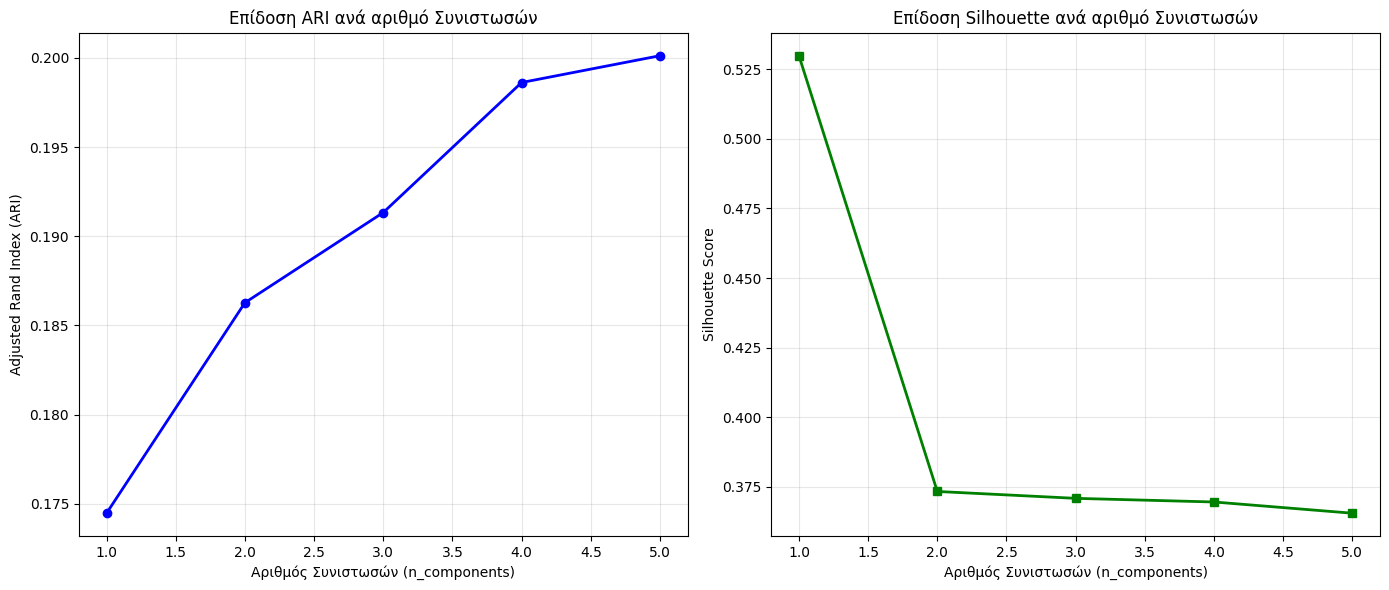

In [26]:
#λίστες για αποθήκευση
n_components_list = [1, 2, 3, 4, 5]
ari_scores = []
silhouette_scores = []

#loop (#5)
for n in n_components_list:

    #pca
    pca = PCA(n_components=n)
    image_pca_new = pca.fit_transform(image_clean)

    #kmeans
    kmeans_new = KMeans(n_clusters=17, random_state=42, n_init=10)
    kmeans_new.fit(image_pca_new)
    labels_new = kmeans_new.labels_

    #μετρικές αξιολόγησης
    #ARI
    ari = adjusted_rand_score(gt_data_clean, labels_new)
    ari_scores.append(ari)

    #Silhouette
    sil = silhouette_score(image_pca_new, labels_new)
    silhouette_scores.append(sil)

#διαγράμματα

plt.figure(figsize=(14, 6))

#διάγραμμα Adjusted Rand Index (ARI)
plt.subplot(1, 2, 1)
plt.plot(n_components_list, ari_scores, marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Επίδοση ARI ανά αριθμό Συνιστωσών')
plt.xlabel('Αριθμός Συνιστωσών (n_components)')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.grid(True, alpha=0.3)

#διάγραμμα Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(n_components_list, silhouette_scores, marker='s', color='green', linestyle='-', linewidth=2)
plt.title('Επίδοση Silhouette ανά αριθμό Συνιστωσών')
plt.xlabel('Αριθμός Συνιστωσών (n_components)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Για τη σύγκριση ανάμεσα στην ακρίβεια και την πολυπλοκότητα που βλέπουμε μεταβάλλοντας τον αριθμό των components στο PCA παρατηρούμε τα εξής:
1. ARI - Adjusted Rand Index:
Παρατηρούμε μια αύξηση στην τιμή του ARI καθώς αυξάνεται ο αριθμός των συνιστωσών (n_components), με τον δείκτη να ξεκινάει από 0.175 και να φτάνει μέχρι το 0.200.
Άρα προσθέτοντας περισσότερες διαστάσεις, προσφέρουμε στον αλγόριθμο KMeans περισσότερη χρήσιμη πληροφορία, επιτρέποντάς του να διαχωρίσει καλύτερα τις καλλιέργειες και να πλησιάσει περισσότερο την πραγματική ταξινόμηση (Ground Truth).
Βέβαια από το n=4 στο n=5 η αύξηση του δείκτη είναι φθίνουσα κάτι που ίσως παραπέμπει σε κορεσμό (saturation) για τη βελτίωση του δείκτη ARI κατά την αύξηση των components.
2. Silhouette Score:
Το Silhouette Score παρουσιάζει την υψηλότερη τιμή του στο n=1, κάτι το οποίο δεν μας αφορά γιατί σε μία διάσταση η δημιουργία κλάσεων είναι τετριμμένη. Από το n=2 μέχρι το n=5 η τιμή της μετρικής σταθεροποιείται σχετικά στο 0.35 περίπου. Αυτό αποδεικνύει ότι η γεωμετρική δομή των δεδομένων διατηρείται συμπαγής στον χώρο χαμηλών διαστάσεων, παρά την προσθήκη νέων συνιστωσών.

Συμπεραίνουμε λοιπόν, ότι το καλύτερο trade-off για ακρίβεια και πολυπλοκότητα είναι οι τιμές n=3 n=4 για τα components. Πιθανά η τιμή n=3 είναι και πιο χρήσιμη γιατί προσφέρει τη δυνατότητα 3D απεικόνισης.

# Μέρος 2: Χρήση προεκπαιδευμένου CNN για συσταδοποίηση

Σε αυτό το μέρος, θα χρησιμοποιήσουμε τη βιβλιοθήκη **Keras**, η οποία παρέχει εύκολη ενσωμάτωση προεκπαιδευμένων μοντέλων CNN και ευκολία στη διαχείριση δεδομένων. Στόχος μας είναι να αναδείξουμε τη δύναμη των χαρακτηριστικών που εξάγονται από προεκπαιδευμένα CNN (Convolutional Neural Networks) για τη συσταδοποίηση δεδομένων τηλεπισκόπησης.

Θα χρησιμοποιήσουμε ένα υποσύνολο από το σύνολο δεδομένων **EuroSAT**, το οποίο αποτελείται από δορυφορικές εικόνες κατανεμημένες σε 10 κατηγορίες (π.χ., καλλιέργειες, δάση, αστικές περιοχές). Τα χαρακτηριστικά που θα εξάγουμε από ένα προεκπαιδευμένο CNN θα χρησιμοποιηθούν για την ομαδοποίηση των εικόνων.

---

## 1. Φόρτωση του συνόλου δεδομένων

Για τους σκοπούς αυτής της άσκησης, θα χρησιμοποιήσουμε το σύνολο δεδομένων **EuroSAT**. Το EuroSAT περιλαμβάνει δορυφορικές εικόνες οργανωμένες σε φακέλους κατά κατηγορία.

---

### 1.α. Κατέβασμα και αποσυμπίεση του EuroSAT

Το EuroSAT δεν υποστηρίζεται απευθείας από το Keras, αλλά μπορείτε να το κατεβάσετε και να το αποσυμπιέσετε με τις παρακάτω εντολές:

```bash
# Κατέβασμα του EuroSAT
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate

# Αποσυμπίεση του αρχείου
!unzip EuroSAT.zip
```

### 1.β. Ενσωμάτωση του Keras μέσω TensorFlow
Η βιβλιοθήκη Keras είναι ενσωματωμένη στο TensorFlow. Για να τη χρησιμοποιήσετε, πρέπει να εισάγετε τη βιβλιοθήκη TensorFlow και να χρησιμοποιήσετε τις κλάσεις της Keras μέσω του tensorflow.keras.

Παρακάτω φαίνεται πώς να φορτώσετε το EuroSAT χρησιμοποιώντας το ImageDataGenerator:


In [27]:
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate
! unzip EuroSAT.zip

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

data_dir = os.path.join('2750')
print(f'Τα δεδομένα βρίσκονται στο: {data_dir}')

# Κανονικοποίηση και φόρτωση των δεδομένων
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.90  # φορτώνουμε ένα μικρό μέρος από κάθε κλάση για γρηγορότερα τρεξίματα θέτοντας μεγάλο validation percentage και φορτώνοντας το training
)

dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224), # το efficientnetb0 δέχεται εικόνες μεγέθους 224 x 224
    batch_size=1, # κάθε κλήση του iterator φορτώνει ένα ζεύγος image - label
    shuffle=False,
    subset='training'
)

print(f'Φορτώθηκαν {len(dataset) * dataset.batch_size} εικόνες.')


Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
  inflating: 2750/SeaLake/SeaLake_967.jpg  
  inflating: 2750/SeaLake/SeaLake_515.jpg  
  inflating: 2750/SeaLake/SeaLake_1465.jpg  
  inflating: 2750/SeaLake/SeaLake_1817.jpg  
  inflating: 2750/SeaLake/SeaLake_2902.jpg  
  inflating: 2750/SeaLake/SeaLake_2570.jpg  
  inflating: 2750/SeaLake/SeaLake_1004.jpg  
  inflating: 2750/SeaLake/SeaLake_174.jpg  
  inflating: 2750/SeaLake/SeaLake_2111.jpg  
  inflating: 2750/SeaLake/SeaLake_2388.jpg  
  inflating: 2750/SeaLake/SeaLake_1948.jpg  
  inflating: 2750/SeaLake/SeaLake_838.jpg  
  inflating: 2750/SeaLake/SeaLake_2738.jpg  
  inflating: 2750/SeaLake/SeaLake_1999.jpg  
  inflating: 2750/SeaLake/SeaLake_2359.jpg  
  inflating: 2750/SeaLake/SeaLake_2660.jpg  
  inflating: 2750/SeaLake/SeaLake_1775.jpg  
  inflating: 2750/SeaLake/SeaLake_605.jpg  
  inflating: 2750/SeaLake/SeaLake_2201.jpg  
  inflating: 2750/SeaLake/SeaLake_264.jpg  
  inflating: 2750/SeaLake/SeaLake_1314.jpg  
  infl

---

## 2. Χρήση προεκπαιδευμένου CNN για Εξαγωγή Χαρακτηριστικών

Σε αυτό το βήμα, θα χρησιμοποιήσετε το προεκπαιδευμένο μοντέλο **EfficientNetB0**, το οποίο είναι διαθέσιμο μέσω της Keras. Το μοντέλο είναι εκπαιδευμένο στο σύνολο δεδομένων **ImageNet** και μπορεί να χρησιμοποιηθεί για την εξαγωγή ισχυρών χαρακτηριστικών από εικόνες. Αυτά τα χαρακτηριστικά θα χρησιμοποιηθούν για τη συσταδοποίηση των δεδομένων.

---

### 2.α. Δημιουργία Εξαγωγέα Χαρακτηριστικών

1. **Φόρτωση του EfficientNetB0**:
   - Χρησιμοποιήστε τη βιβλιοθηκη `tensorflow.keras.applications` για να φορτώσετε το προεκπαιδευμένο μοντέλο **EfficientNetB0**.
   - Φροντίστε να ρυθμίσετε την παράμετρο `include_top=False` για να αφαιρέσετε το τελικό στρώμα ταξινόμησης.

2. **Pooling**:
   - Ενεργοποιήστε τη μέθοδο μέσου όρου (average pooling) στο τελικό στρώμα με την παράμετρο `pooling='avg'`. Αυτό θα εξασφαλίσει τη συμπύκνωση των χαρακτηριστικών σε έναν διαχειρίσιμο αριθμό διαστάσεων.


In [29]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

#δημιουργούμε το μοντέλο EfficientNetB0
model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
#με το include_top=False δεν κάνουμε την τελική ταξινόμηση γιατί θα την εφαρμόσουμε εμείς παίρνουμε μόνο τις πληροφορίες
#με το pooling='avg' παίρνουμε τον μέσο όρο και τον μετατρέπουμε σε απλή λίστα 1280 χαρακτηριστικών. (όχι που είναι αλλά υπάρχουν)

print("Το μοντέλο φορτώθηκε επιτυχώς!")
model.summary() #τι κάνει το κάθε στρώμα, πως αλλάζει το μέγεθος των δεδομένων καθώς προχωράνε στο δίκτυο (συμπύκνωση),
                #trainable parameters

Το μοντέλο φορτώθηκε επιτυχώς!


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, None,      │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, None,      │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, None,      │          0 │ normalization_1[… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

### 2.β. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Χρησιμοποιήστε τον εξαγωγέα χαρακτηριστικών που δημιουργήσατε για να επεξεργαστείτε το σύνολο δεδομένων (`dataset`) και να εξαγάγετε τα χαρακτηριστικά των εικόνων μέσω της μεθόδου `.predict()`. Αποθηκεύστε τα εξαγόμενα χαρακτηριστικά σε μια μεταβλητή και εκτυπώστε τις διαστάσεις τους για να επιβεβαιώσετε ότι η εξαγωγή έγινε σωστά. Τα χαρακτηριστικά αυτά θα χρησιμοποιηθούν στο επόμενο βήμα για συσταδοποίηση.


In [35]:
#εξαγωγή χαρακτηριστικών
cnn_features = model.predict(dataset)

# 2. Αποθήκευση των πραγματικών κατηγοριών (Labels)
true = dataset.classes #το dataset.classes είναι μια λίστα που έχει τον σωστό αριθμό για κάθε μία από
                         #τις 2.700 (έτοιμες κατηγοριοποιημένες - πραγματικότητα)

#έλεγχος διαστάσεων
print(f"Διαστάσεις χαρακτηριστικών (cnn_features): {cnn_features.shape}")
print(f"Διαστάσεις ετικετών (y_true): {true.shape}")

2700/2700 ━━━━━━━━━━━━━━━━━━━━ 226s 84ms/step
Διαστάσεις χαρακτηριστικών (cnn_features): (2700, 1280)
Διαστάσεις ετικετών (y_true): (2700,)


### 2.γ. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Εφαρμόστε τον αλγόριθμο **KMeans** στα χαρακτηριστικά που εξήχθησαν θέτωντας αριθμό συστάδων 10, και υπολογίστε τη μετρική Adjusted Rand Index.

In [36]:
#δημιουργούμε το μοντέλο kmeans με 10 ομάδες (συστάδες) γιατί τόσες είναι οι κατηγορίες του ΕuroSAT
kmeans_cnn = KMeans(n_clusters=10, random_state=42, n_init=10)

#εκπαίδευση στα 1280 χαρακτηριστικά που πριν πήραμε
kmeans_cnn.fit(cnn_features)

#παίρνουμε τις ετικέτες που αποφάσισε ο KMeans
labels_cnn = kmeans_cnn.labels_

In [37]:
#ARI
#συγκρίνουμε τις προβλέψεις του KMeans με την πραγματικότητα (true) που προηγουμένως αποθηκεύσαμε στο true
ari_cnn = adjusted_rand_score(true , labels_cnn)

print(f"Adjusted Rand Index (CNN Features): {ari_cnn:.4f}")

Adjusted Rand Index (CNN Features): 0.5207


Παρατηρούμε ότι τωρά με τη χρήση του προεκπαιδευμένου νευρωνικού δικτύου το αποτελέσμα του μετρικού δείκτη ARI είναι αρκετά αυξημένο.
Το αποτέλεσμα αυτό δείχνει ότι η μέθοδος Μεταφοράς Μάθησης (Transfer Learning) είναι αποτελεσματική, κάτι το οποίο ήταν αναμενόμενο αφού τα χαρακτηριστικά που παίρνουμε από το CNN είναι high-level features. Το νευρωνικό δίκτυο κωδικοποιεί πληροφορίες σχετικά με τη γεωμετρία, την υφή και τα χωρικά μοτίβα των αντικειμένων, άρα ο χώρος που δημιουργεί το CNN είναι πολύ πιο διαχωρίσιμος, επιτρέποντας στον αλγόριθμο KMeans να εντοπίσει με μεγαλύτερη ακρίβεια τις σημασιολογικές ομάδες και να κάνει σωστή αντιστοίχιση.
Αντίθετα ο αρχικός kmeans έπαιρνε σαν είσοδο ακατέργαστα pixels που περιέχουν μόνο πληροφορία φωτεινότητας και χρώματος, τα οποία συχνά παρουσιάζουν αλληλοεπικάλυψη μεταξύ διαφορετικών κλάσεων.

### 2δ: Συσταδοποίηση Χρησιμοποιώντας Μόνο τις τιμές των Pixel

Σε αυτήν την τελευταία φάση, θα επαναλάβετε τη συσταδοποίηση **χωρίς τη χρήση προεκπαιδευμένου μοντέλου CNN**, αλλά χρησιμοποιώντας μόνο τα pixel των εικόνων ως χαρακτηριστικά.

1. **Κανονικοποίηση των Pixel**:
   - Κάθε εικόνα πρέπει να αναδιαταχθεί σε έναν μονοδιάστατο πίνακα και να κανονικοποιηθεί στις τιμές [0, 1].

2. **Ενοποίηση Δεδομένων**:
   - Συνδυάστε τα δεδομένα από όλες τις εικόνες σε έναν μεγάλο πίνακα με διαστάσεις `(N, M)`, όπου:
     - `N`: Ο αριθμός των εικόνων.
     - `M`: Ο αριθμός των pixel κάθε εικόνας.

3. **Εφαρμογή του KMeans**:
   - Χρησιμοποιήστε τον αλγόριθμο KMeans για τη συσταδοποίηση των εικόνων.

4. **Υπολογισμός Μετρικών**:
   - Υπολογίστε τον Adjusted Rand Index.

5. **Σύγκριση Αποτελεσμάτων**:
   - Συγκρίνετε τα αποτελέσματα με τη συσταδοποίηση που έγινε χρησιμοποιώντας τα χαρακτηριστικά από το CNN.

---


In [42]:
#1: κανονικοποίηση pixel
#ξαναδιαβάζουμε δεδομένα
dataset.reset()

#δημιουγούμε λίστες για αποθήκευση
all_images = []
all_labels = []

#παίρνουμε όλες τις εικόνες
for i in range(len(dataset)):
    img, label = next(dataset)
    all_images.append(img)
    all_labels.append(label)

# Μετατρέπουμε σε numpy array
raw = np.concatenate(all_images) #ενιαίος πίνακας με τις 2700 εικόνες μαζεμένες
true_raw = np.argmax(np.concatenate(all_labels), axis=1) #argmax κάνει το one-hot encoding σε μορφή κλάσης (αριθμό)

print(f"Αρχικό σχήμα εικόνων: {raw.shape}")  #3 χρωματα rgb δίνει το EuroSAT

Αρχικό σχήμα εικόνων: (2700, 224, 224, 3)


In [45]:
#2: ενοποίηση δεδομένων
#κάθε εικόνα γίνεται μια τεράστια γραμμή
n_samples = raw.shape[0]
raw_flattened = raw.reshape(n_samples, -1)

print(f"Σχήμα μετά το Flatten: {raw_flattened.shape}")

Σχήμα μετά το Flatten: (2700, 150528)


In [46]:
#3: εφαρμογή του kmeans
kmeans_pixel = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_pixel.fit(raw_flattened)
labels_pixel = kmeans_pixel.labels_

In [47]:
#4: υπολογισμός μετρικών
ari_pixel = adjusted_rand_score(true_raw, labels_pixel)

print(f"ARI (Raw Pixels): {ari_pixel:.4f}")
print(f"ARI (CNN Features): {ari_cnn:.4f}")

ARI (Raw Pixels): 0.1506
ARI (CNN Features): 0.5207


Συγκρίναμε την απόδοση της συσταδοποίησης χρησιμοποιώντας τα ακατέργαστα pixels των εικόνων EuroSAT.
Το αποτέλεσμα ARI για τα raw pixels είναι όπως βλέπουμε αρκετά χαμηλό, γεγονός που αποδεικνύει ότι η απλή χρωματική πληροφορία των pixels δεν επαρκεί για τον διαχωρισμό πολύπλοκων σκηνών όπως αυτές των δορυφορικών εικόνων.

### 2.ε. Οπτικοποίηση αποτελεσμάτων

Χρησιμοποιήστε τα αποτελέσματα της συσταδοποίησης τόσο από τα χαρακτηριστικά που εξήχθησαν μέσω του CNN όσο και από τις τιμές των pixel. Για κάθε μέθοδο, επιλέξτε τυχαία 5 εικόνες από κάθε συστάδα και απεικονίστε τες σε ένα πλέγμα (grid), με χρήση της βιβλιοθήκης matplotlib.

Εξηγήστε τα αποτελέσματα της συσταδοποίησης:
- Είναι εμφανής ο διαχωρισμός των εικόνων σε συστάδες;
- Παρατηρείτε κοινά χαρακτηριστικά ή μοτίβα στις εικόνες κάθε συστάδας;
- Πώς συγκρίνονται οι συστάδες που δημιουργήθηκαν από τα χαρακτηριστικά του CNN με αυτές που δημιουργήθηκαν από τις τιμές των pixel;

Αναλύστε εάν η χρήση των χαρακτηριστικών που εξήχθησαν από το CNN βοήθησε στον καλύτερο διαχωρισμό των δεδομένων και πώς αυτό αντανακλά στις συστάδες και τα περιεχόμενά τους.

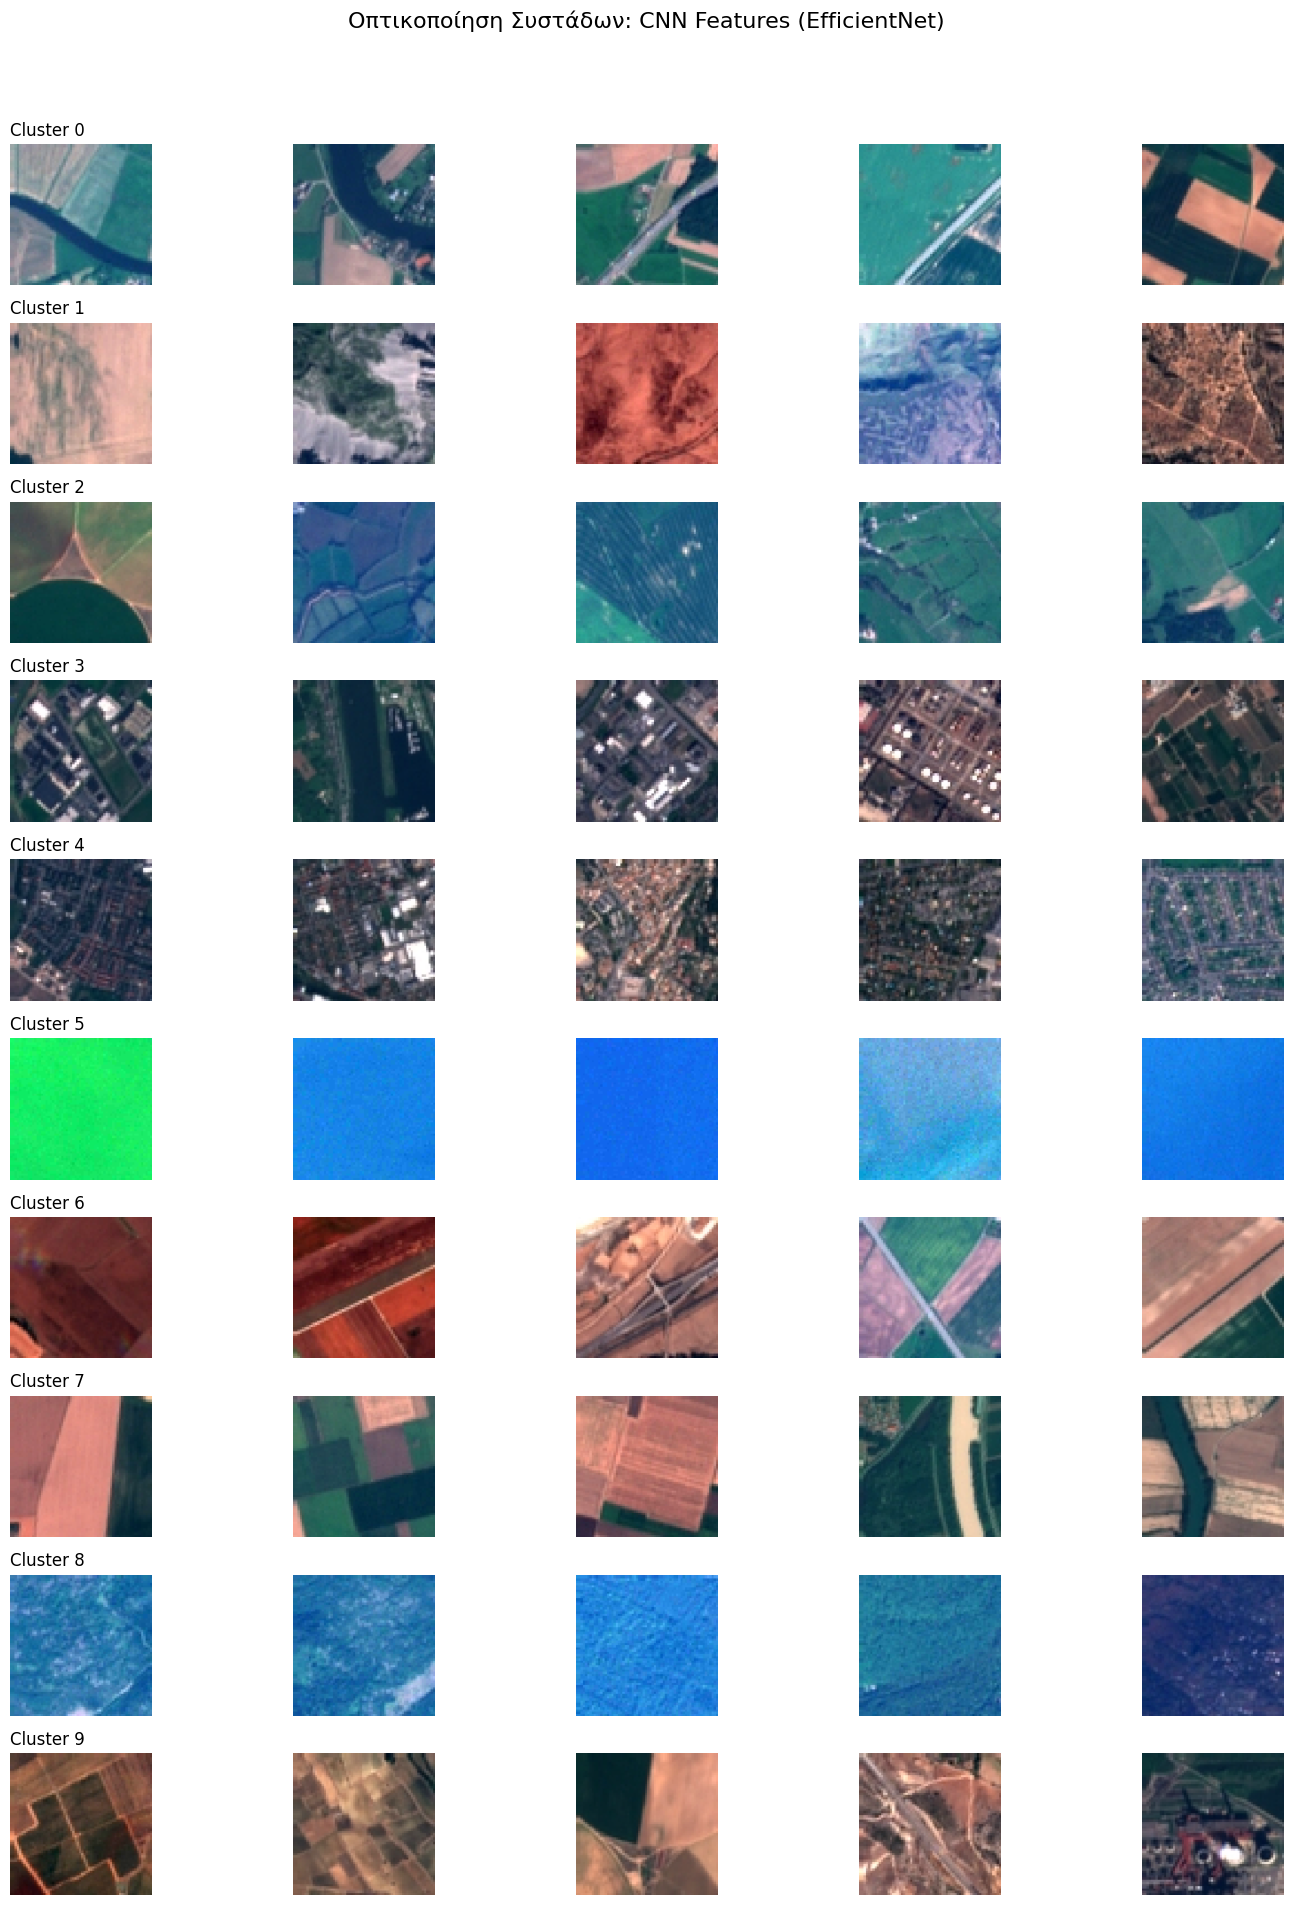

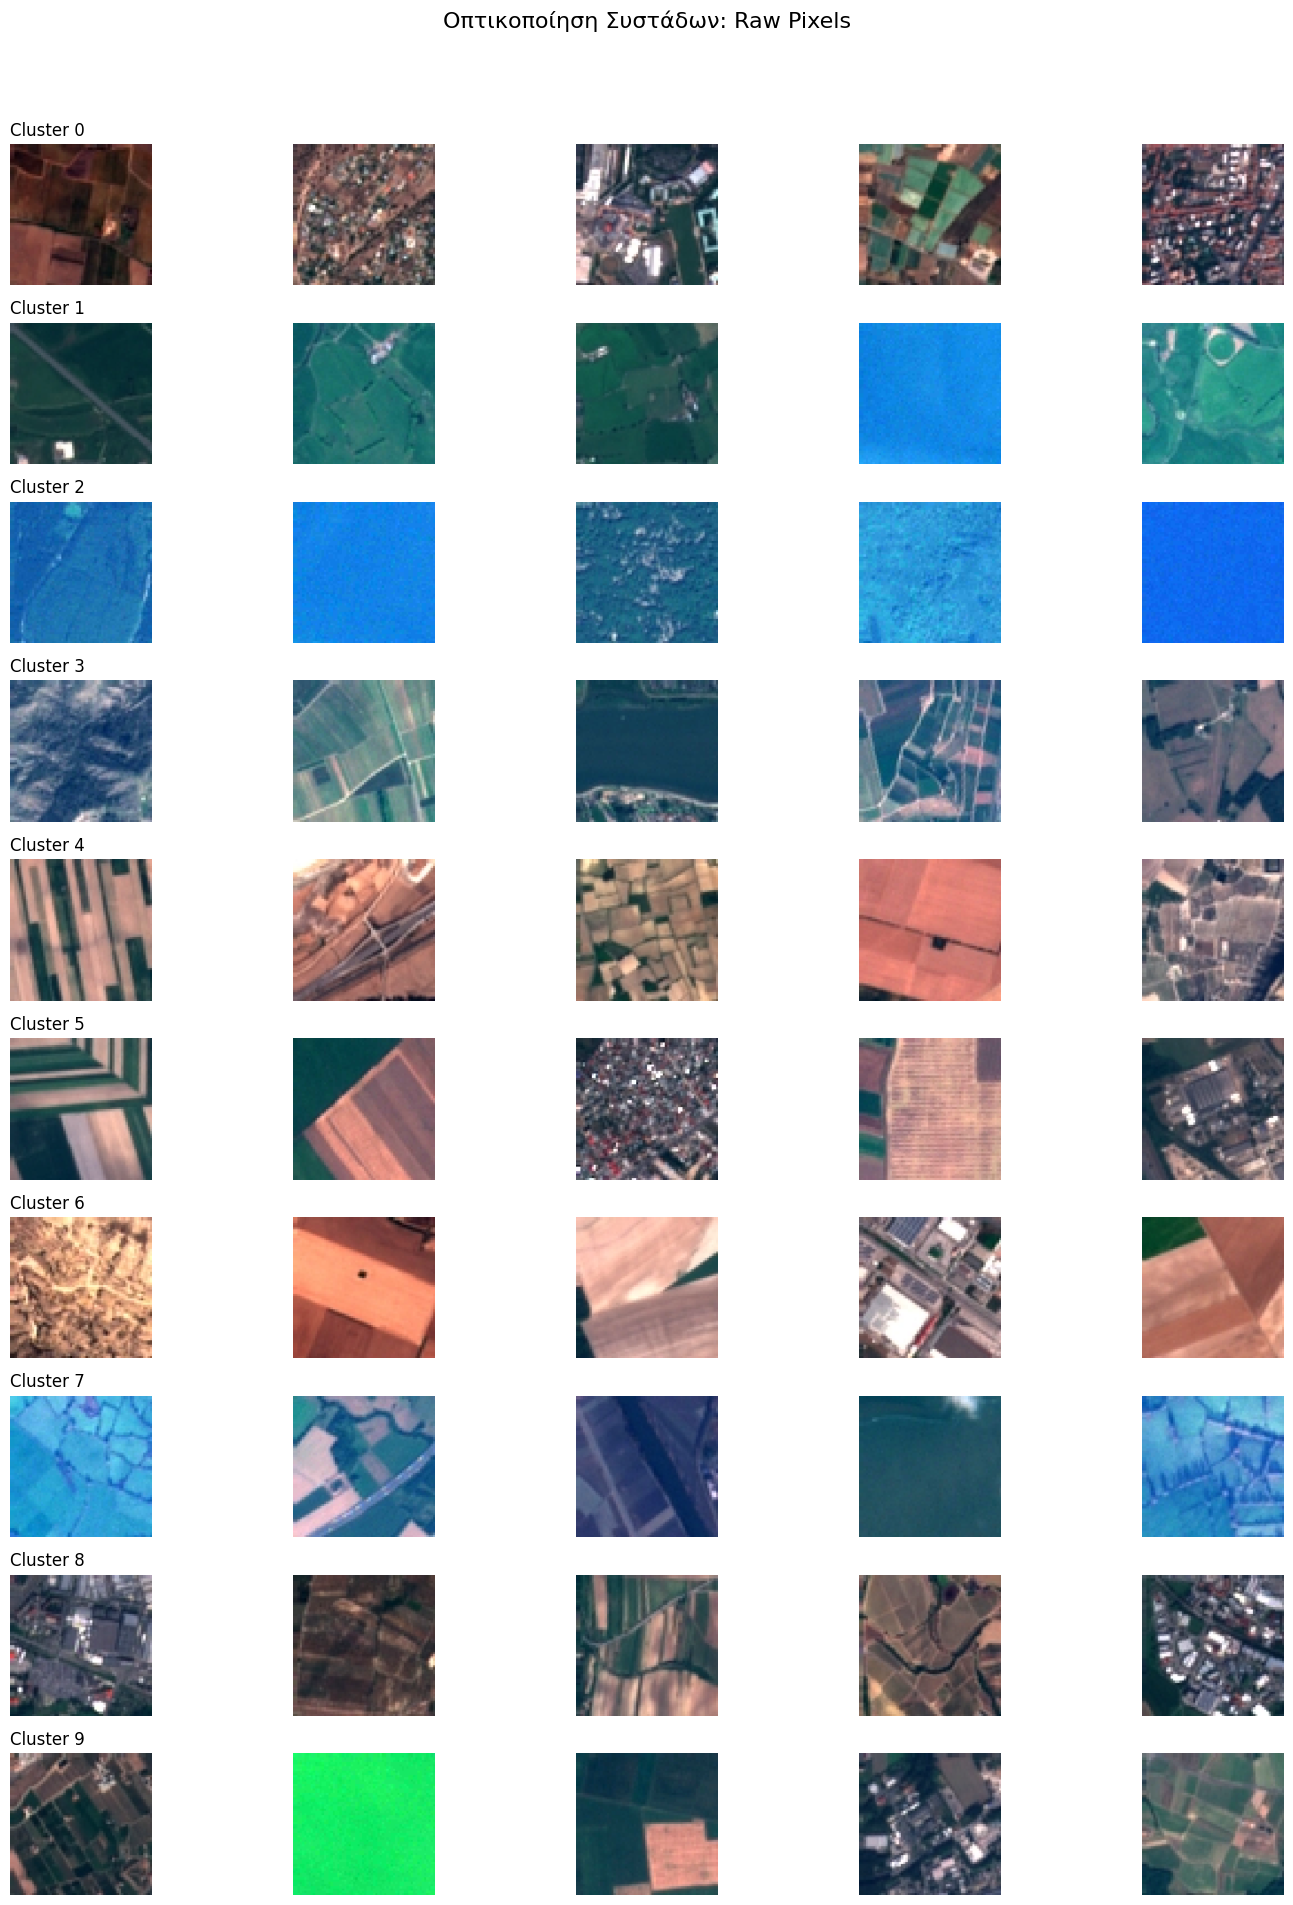

In [50]:
# Συνάρτηση για την οπτικοποίηση

def visualize_clusters(images, labels, method_name):
    #πλέγμα 10 γραμμές (Clusters), 5 στήλες (Εικόνες)
    fig, axes = plt.subplots(10, 5, figsize=(15, 20))
    fig.suptitle(f'Οπτικοποίηση Συστάδων: {method_name}', fontsize=16)

    for cluster_id in range(10):
        #ποιες εικόνες ανήκουν στο cluster
        indices = np.where(labels == cluster_id)[0]

        #τυχαία 5 εικόνες
        if len(indices) >= 5:
            selected_indices = np.random.choice(indices, 5, replace=False)
        else:
            selected_indices = indices

        #εμφάνιση εικόνων
        for i, idx in enumerate(selected_indices):
            ax = axes[cluster_id, i]

            #κανονικοποίηση εικόνων
            img_to_show = images[idx]
            img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min())

            ax.imshow(img_to_show)
            ax.axis('off')

            if i == 0:
                ax.set_title(f'Cluster {cluster_id}', fontsize=12, loc='left')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ρύθμιση περιθωρίων
    plt.show()

#εφαρμόζω συνάρτηση

#CNN Features
visualize_clusters(raw, labels_cnn, "CNN Features (EfficientNet)")

#Raw Pixels
visualize_clusters(raw, labels_pixel, "Raw Pixels")

**Είναι εμφανής ο διαχωρισμός των εικόνων σε συστάδες;**


---


**CNN (EfficientNet):** O διαχωρισμός είναι εμφανής. Παρατηρούμε ότι κάθε γραμμή (συστάδα) περιέχει εικόνες που είναι οπτικά και εννοιολογικά συνεπείς μεταξύ τους. Υπάρχει υψηλός βαθμός ομοιογένειας εντός των ομάδων.
**Raw Pixels:** Όχι, ο διαχωρισμός δεν είναι σαφής ως προς το περιεχόμενο. Mερικές από τις συστάδες φαίνεται να είναι μπερδεμένες, με διαφορετικά είδη τοπίων να αναμιγνύονται στην ίδια ομάδα (πχ. κτήρια με χωράφια στο cluster 0 και χωράφια με μία πράσινη εικόνα cluster 9).

**Παρατηρείτε κοινά χαρακτηριστικά ή μοτίβα στις εικόνες κάθε συστάδας;**


---

**CNN**: Τα κοινά χαρακτηριστικά είναι σημασιολογικά (semantic). Το νευρωνικό δίκτυο εντόπισε μοτίβα υψηλού επιπέδου, όπως δρόμους, γραμμικά διαχωρισμένες περιοχές με κτήρια, οικόπεδα με βλάστηση χωρισμένα.
**Raw Pixels:** Τα κοινά χαρακτηριστικά είναι κυρίως χρωματικά (chromatic) και αφορούν τη φωτεινότητα πχ μπλε κατηγοριοποιήση, γκρι κατηγοριοποίηση στα κτήρια και πιο θερμά τοπία μαζί ανεξαρτήτως του τι απεικονίζουν.

**Πώς συγκρίνονται οι συστάδες που δημιουργήθηκαν από τα χαρακτηριστικά του CNN με αυτές που δημιουργήθηκαν από τις τιμές των pixel;**


---
Οι συστάδες του **CNN** αντιστοιχούν σε πραγματικές κατηγορίες εδάφους. Το μοντέλο "κατάλαβε" το αντικείμενο, επιτυγχάνοντας σωστό διαχωρισμό ακόμα και όταν τα χρώματα διέφεραν ελαφρώς.

Αντίθετα, οι συστάδες των **Pixels** είναι ρηχές. Βασίζονται μόνο στην κατανομή των χρωμάτων (ιστόγραμμα), με αποτέλεσμα να αποτυγχάνουν να διακρίνουν αντικείμενα που έχουν παρόμοιο χρώμα αλλά εντελώς διαφορετική δομή.


**Συμπέρασμα**:


---


Για την ανάλυση πολύπλοκων δεδομένων τηλεπισκόπησης, οι μέθοδοι που βασίζονται σε ακατέργαστα δεδομένα (Pixels) ή απλή μείωση διαστάσεων (PCA) είναι ανεπαρκείς λόγω της υψηλής αλληλοεπικάλυψης των φασματικών υπογραφών.

Η εφαρμογή τεχνικών Μεταφοράς Μάθησης (Transfer Learning) μέσω βαθιών νευρωνικών δικτύων (CNNs) αποδείχθηκε η βέλτιστη προσέγγιση, καθώς επέτρεψε την εξαγωγή σημασιολογικών χαρακτηριστικών που οδήγησαν σε ακριβή και ερμηνεύσιμη συσταδοποίηση των δορυφορικών εικόνων. Το CNN μετέτρεψε το πρόβλημα από "διαχωρισμό χρωμάτων" σε "αναγνώριση αντικειμένων".